In [3]:
from typing import TypedDict
from typing import Literal

from pydantic import BaseModel

from langchain_ollama import ChatOllama

from langgraph.graph import (
    StateGraph,
    START,
    END
)

from langchain_mcp_adapters.client import (
    MultiServerMCPClient
)

In [4]:
MAX_STEPS = 10
MAX_RESEARCH_ITERATIONS = 2

MAX_SEARCH_RESULTS = 5
MAX_DOCUMENTS = 3

In [47]:
class ResearchState(TypedDict):

    query: str

    research_results: list

    documents: list

    analysis: str

    review: dict

    summary: str

    step_count: int

    execution_history: list

    next_agent: str

    supervisor_reason: str

In [48]:
initial_state = {

    "query":
        "What are the latest developments in RAG?",

    "research_results": [],

    "documents": [],

    "analysis": "",

    "review": {},

    "summary": "",

    "step_count": 0,

    "execution_history": [],

    "next_agent": "",

    "supervisor_reason": ""
}

In [49]:
llm = ChatOllama(
    model="qwen2.5:3b",
    temperature=0
)

In [50]:
response = llm.invoke(
    "Explain MCP in one sentence."
)

print(response.content)

MCP (Managed Compute Resources) is a service in Alibaba Cloud that allows users to easily manage and scale compute resources for their applications.


In [51]:
mcp_client = MultiServerMCPClient(
    {
        "research_tools": {
            "transport": "http",
            "url": "http://localhost:8000/mcp"
        }
    }
)

In [52]:
tools = await mcp_client.get_tools()

In [53]:
for tool in tools:

    print(
        f"Tool: {tool.name}"
    )

    print(
        f"Description: {tool.description}"
    )

    print("-" * 50)

Tool: search_web
Description: 
    Search the web for information about a topic.
    
--------------------------------------------------


In [54]:
from langchain_core.tools import BaseTool

In [55]:
search_tool = next(
    tool
    for tool in tools
    if tool.name == "search_web"
)

In [56]:
async def research_agent(
    state: ResearchState
):

    print("\n🔎 RESEARCH AGENT")

    query = state["query"]

    results = await search_tool.ainvoke(
        {
            "query": query
        }
    )

    return {

        "research_results": results,

        "step_count":
            state["step_count"] + 1,

        "execution_history":
            state["execution_history"]
            + ["research"]
    }

In [57]:
async def extraction_agent(
    state: ResearchState
):

    print("\n📄 EXTRACTION AGENT")

    research_results = (
        state["research_results"]
    )

    documents = [
        {
            "title": "Research Result",
            "content": research_results
        }
    ]

    return {

        "documents": documents,

        "step_count":
            state["step_count"] + 1,

        "execution_history":
            state["execution_history"]
            + ["extraction"]
    }

In [58]:
async def analysis_agent(
    state: ResearchState
):

    print("\n🧠 ANALYSIS AGENT")

    context = "\n\n".join(
        str(doc)
        for doc in state["documents"]
    )

    prompt = f"""
You are the Analysis Agent.

User Question:
{state["query"]}

Research Data:
{context}

Analyze the research.

Identify:

1. Main findings
2. Important facts
3. Trends
4. Limitations

Do not perform additional research.

Return only the analysis.
"""

    response = await llm.ainvoke(
        prompt
    )

    return {

        "analysis":
            response.content,

        "step_count":
            state["step_count"] + 1,

        "execution_history":
            state["execution_history"]
            + ["analysis"]
    }

In [59]:
class ReviewResult(BaseModel):

    decision: Literal[
        "APPROVED",
        "NEEDS_MORE"
    ]

    reason: str

    missing_information: list[str]

In [60]:
review_llm = llm.with_structured_output(
    ReviewResult
)

In [61]:
async def reviewer_agent(
    state: ResearchState
):

    print("\n🔍 REVIEWER AGENT")

    prompt = f"""
You are a strict research reviewer.

Question:
{state["query"]}

Analysis:
{state["analysis"]}

Evaluate whether the analysis is
sufficient to provide a useful answer.

Return:

APPROVED
or
NEEDS_MORE

Do NOT perform additional research.

If information is incomplete, explain
what is missing.
"""

    result = await review_llm.ainvoke(
        prompt
    )

    return {

        "review":
            result.model_dump(),

        "step_count":
            state["step_count"] + 1,

        "execution_history":
            state["execution_history"]
            + ["reviewer"]
    }

In [62]:
async def summary_agent(
    state: ResearchState
):

    print("\n📝 SUMMARY AGENT")

    prompt = f"""
You are the Summary Agent.

Question:
{state["query"]}

Analysis:
{state["analysis"]}

Review:
{state["review"]}

Create a concise, useful final answer.

If the reviewer identified missing
information, clearly mention that the
answer is based on the available research.

Do not invent facts.

Return only the final answer.
"""

    response = await llm.ainvoke(
        prompt
    )

    return {

        "summary":
            response.content,

        "step_count":
            state["step_count"] + 1,

        "execution_history":
            state["execution_history"]
            + ["summary"]
    }

In [ ]:
class SupervisorDecision(BaseModel):

    next_agent: Literal[
        "research",
        "extraction",
        "analysis",
        "reviewer",
        "summary",
        "finish"
    ]

    reason: str

In [ ]:
supervisor_llm = llm.with_structured_output(
    SupervisorDecision
)

In [ ]:
async def supervisor_node(
    state: ResearchState
):

    history = state[
        "execution_history"
    ]

    if "research" not in history:

        next_agent = "research"

        reason = (
            "Research has not been performed yet."
        )

    elif "extraction" not in history:

        next_agent = "extraction"

        reason = (
            "Research exists; "
            "extraction is required."
        )

    elif "analysis" not in history:

        next_agent = "analysis"

        reason = (
            "Documents exist; "
            "analysis is required."
        )

    elif "reviewer" not in history:

        next_agent = "reviewer"

        reason = (
            "Analysis exists; "
            "review is required."
        )

    elif "summary" not in history:

        next_agent = "summary"

        reason = (
            "Review completed; "
            "generate final summary."
        )

    else:

        next_agent = "finish"

        reason = (
            "All agents completed."
        )

    return {

        "next_agent":
            next_agent,

        "supervisor_reason":
            reason,

        "execution_history":
            history + ["supervisor"]
    }

In [ ]:
builder = StateGraph(
    ResearchState
)

In [ ]:
builder.add_node(
    "supervisor",
    supervisor_agent
)

builder.add_node(
    "research",
    research_agent
)

builder.add_node(
    "extraction",
    extraction_agent
)

builder.add_node(
    "analysis",
    analysis_agent
)

builder.add_node(
    "reviewer",
    reviewer_agent
)

builder.add_node(
    "summary",
    summary_agent
)

In [ ]:
builder.add_edge(
    START,
    "supervisor"
)

In [ ]:
def supervisor_router(
    state: ResearchState
):

    if state["step_count"] >= 10:

        return "finish"

    return state["next_agent"]

In [ ]:
async def supervisor_node(
    state: ResearchState
):

    decision = await supervisor_agent(
        state
    )

    return {
        "next_agent":
            decision["next_agent"],

        "execution_history":
            state["execution_history"]
            + ["supervisor"]
    }

In [ ]:
builder.add_conditional_edges(

    "supervisor",

    supervisor_router,

    {
        "research":
            "research",

        "extraction":
            "extraction",

        "analysis":
            "analysis",

        "reviewer":
            "reviewer",

        "summary":
            "summary",

        "finish":
            END
    }
)

In [ ]:
builder.add_edge(
    START,
    "supervisor"
)

In [74]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

research_graph = builder.compile(
    checkpointer=checkpointer
)

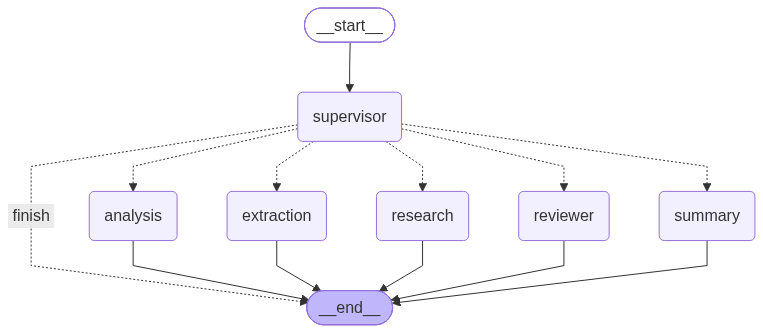

In [75]:
from IPython.display import Image, display

display(
    Image(
        research_graph
        .get_graph()
        .draw_mermaid_png()
    )
)

In [76]:
import os
from dotenv import load_dotenv

load_dotenv()

print(
    os.getenv("LANGSMITH_PROJECT")
)

AI-Research-MCP


In [77]:
config = {

    "configurable": {
        "thread_id":
            "research-001"
    },

    "recursion_limit": 20,

    "run_name":
        "AI Research Multi-Agent",

    "tags": [
        "multi-agent",
        "mcp",
        "langgraph",
        "qwen"
    ],

    "metadata": {

        "model":
            "qwen2.5:3b",

        "architecture":
            "supervisor-sequential",

        "max_steps":
            10
    }
}

In [ ]:
async for update in research_graph.astream(
    initial_state,
    config=config,
    stream_mode="updates"
):
    
    print("\n" + "=" * 60)

    for node, output in update.items():

        print(f"NODE: {node}")
        print(output)

KeyError: 'research_iterations'